In [1]:
import data_loader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [2]:
df = data_loader.load_data_csv("../data/bigmart_sales.csv")

In [3]:
# 1. Общая информация о данных 
print("📋 Размер данных:", df.shape)
print("\n🔍 Типы данных:")
print(df.dtypes)
print("\n📦 Пропуски в данных:")
print(df.isna().sum())
print("\n📈 Основная статистика:")
print(df.describe(include='all').T)

📋 Размер данных: (14204, 12)

🔍 Типы данных:
Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
dtype: object

📦 Пропуски в данных:
Item_Identifier                 0
Item_Weight                  2439
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  4016
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

📈 Основная статистика:
                             c

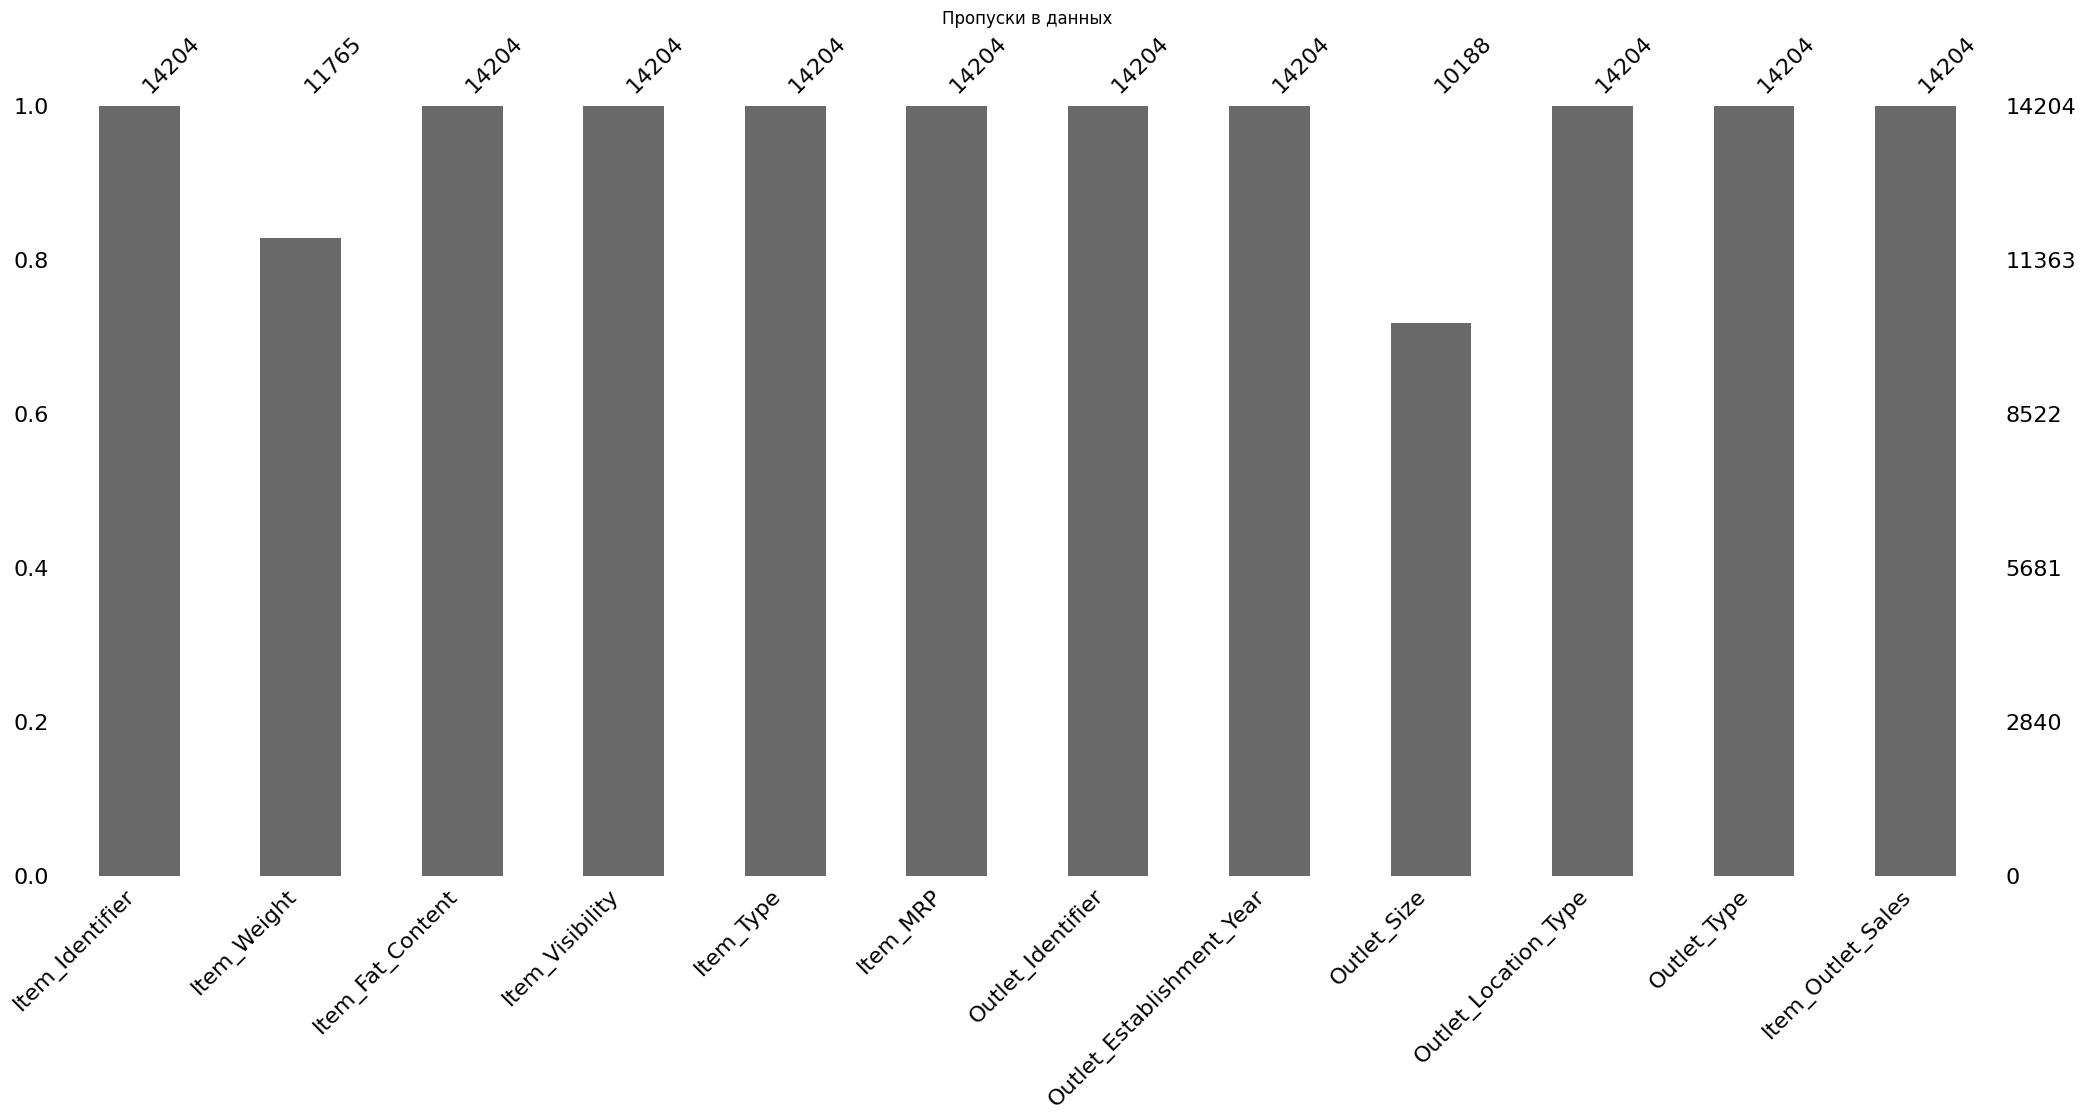

In [4]:
# 2. Визуализация пропусков
plt.figure(figsize=(10, 5))
msno.bar(df)
plt.title("Пропуски в данных")
plt.show()

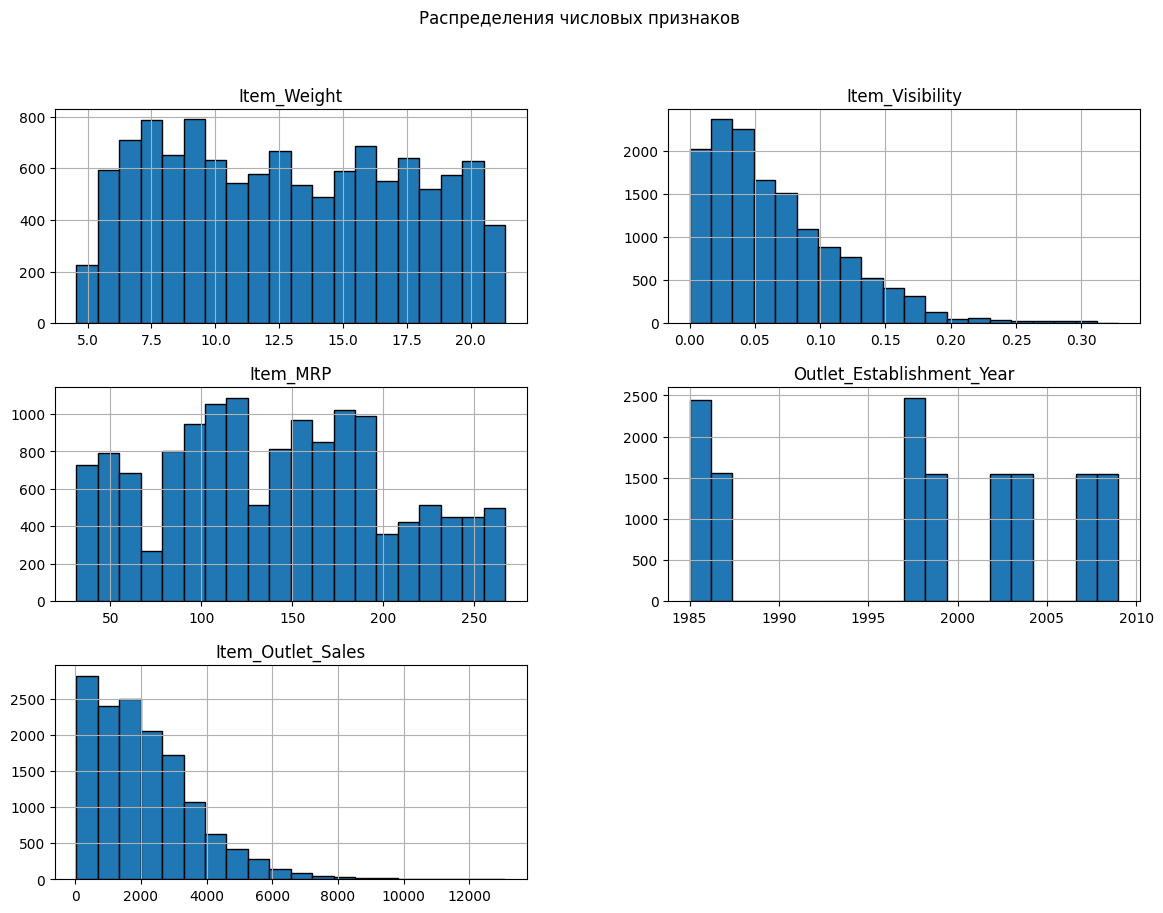

In [5]:
# 3. Распределения числовых признаков
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].hist(bins=20, figsize=(14, 10), edgecolor='black')
plt.suptitle("Распределения числовых признаков")
plt.show()

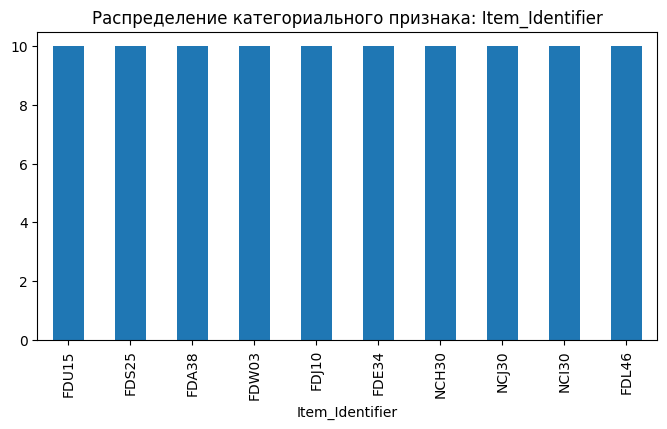

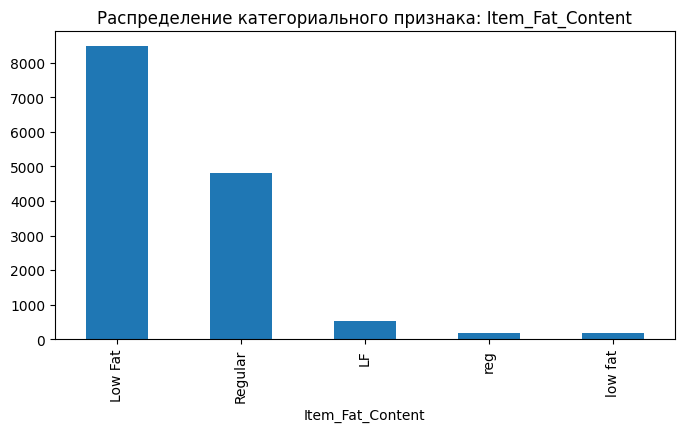

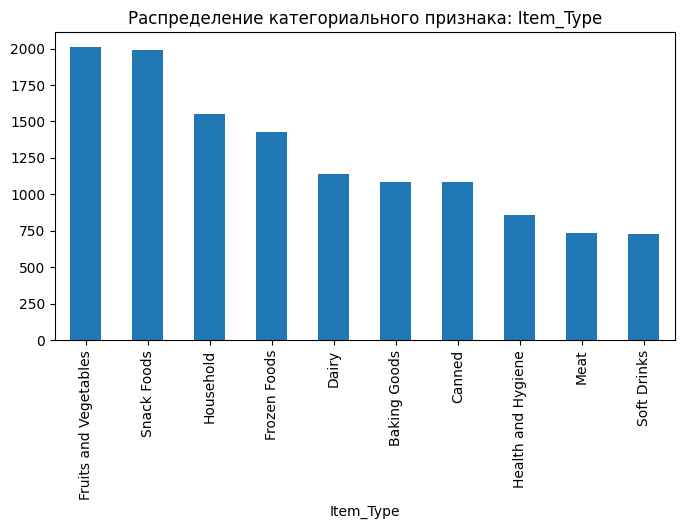

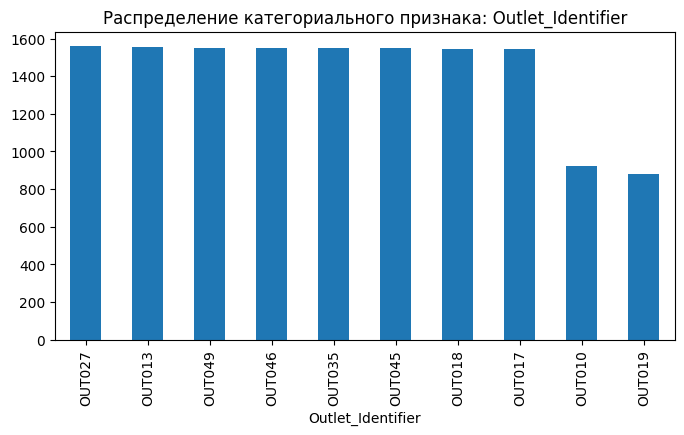

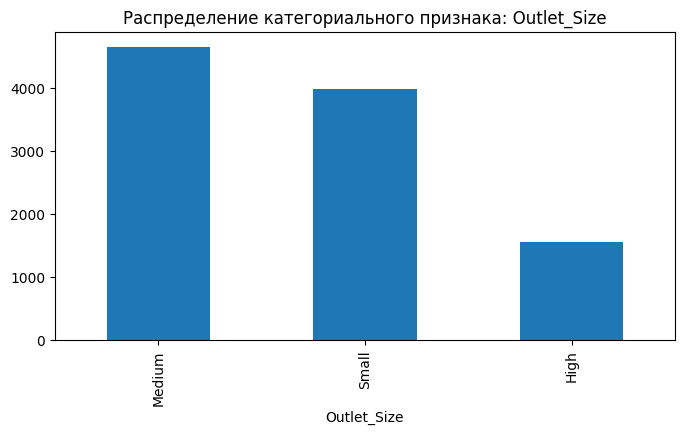

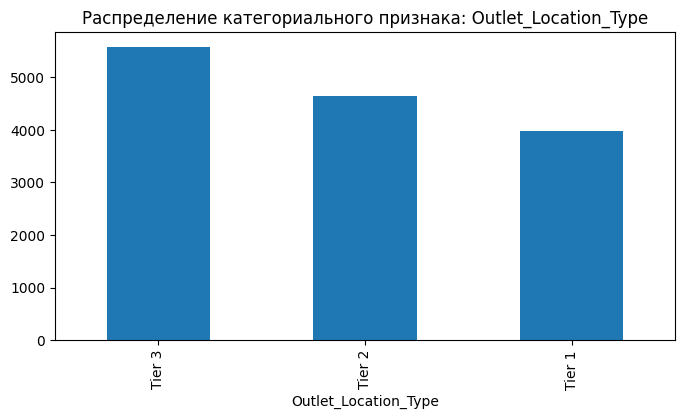

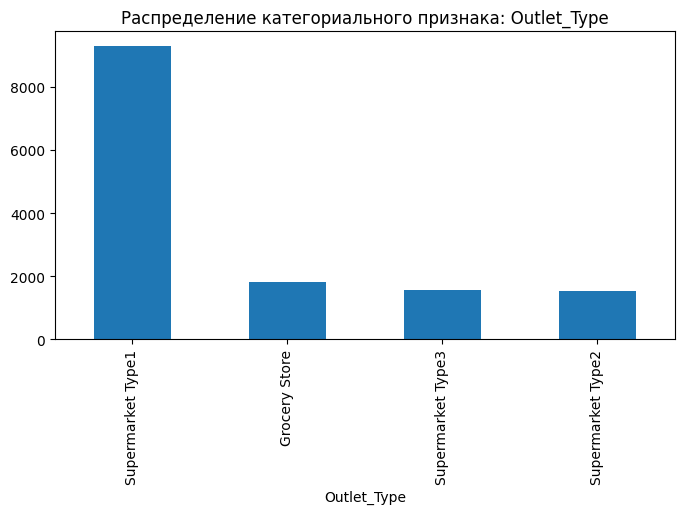

In [6]:
# 4. Анализ категориальных признаков
cat_cols = df.select_dtypes(exclude=np.number).columns
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f"Распределение категориального признака: {col}")
    plt.show()

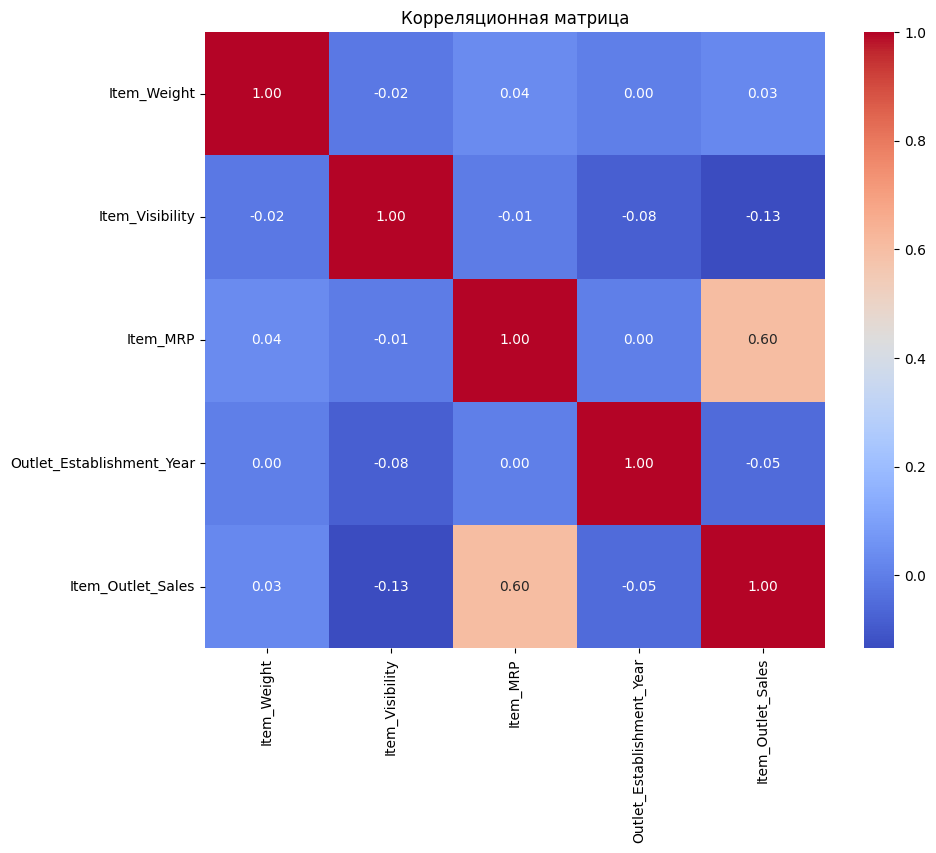

In [7]:
# 5. Корреляции числовых признаков
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляционная матрица")
plt.show()

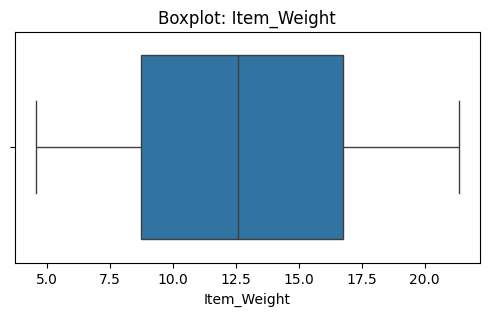

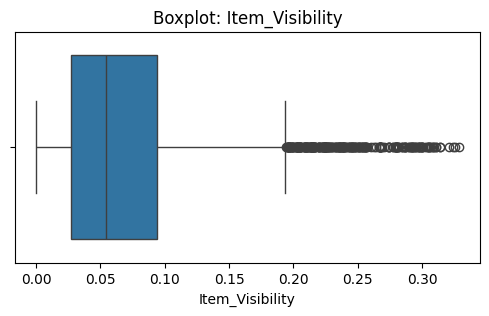

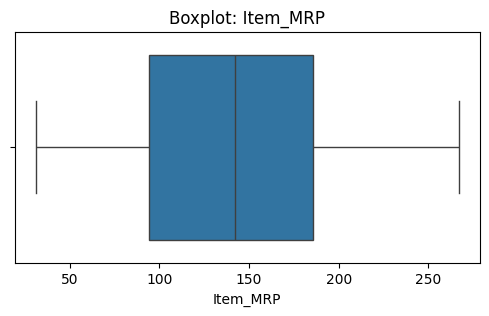

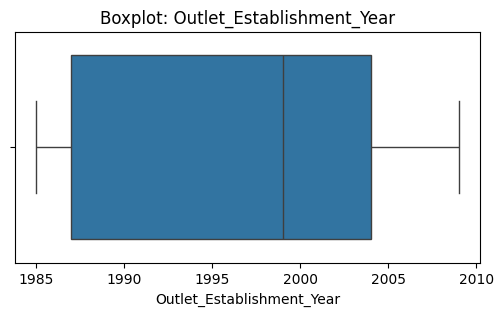

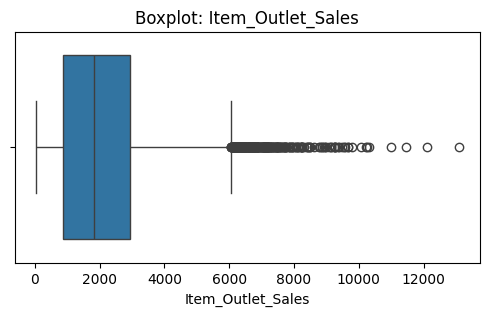

In [8]:
# 6. Проверка выбросов
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

In [9]:
# 7. Уникальные значения и дубликаты
print("\n Количество уникальных значений по признакам:")
print(df.nunique())

duplicates = df.duplicated().sum()
print(f"\n Дубликатов строк: {duplicates}")


 Количество уникальных значений по признакам:
Item_Identifier               1559
Item_Weight                    415
Item_Fat_Content                 5
Item_Visibility              13006
Item_Type                       16
Item_MRP                      8052
Outlet_Identifier               10
Outlet_Establishment_Year        9
Outlet_Size                      3
Outlet_Location_Type             3
Outlet_Type                      4
Item_Outlet_Sales             9174
dtype: int64

 Дубликатов строк: 0


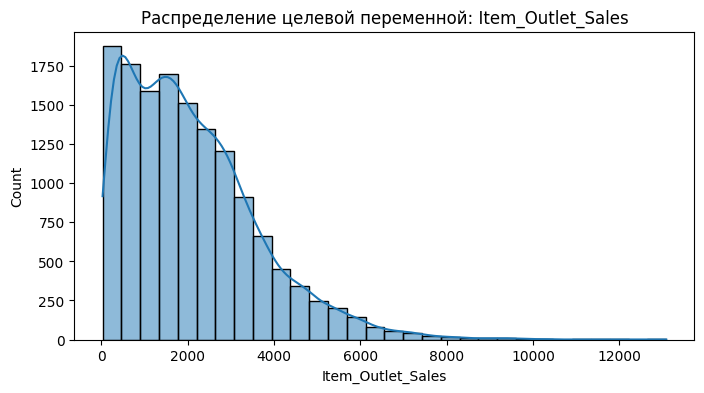


 Корреляция признаков с целевой переменной:
Item_Outlet_Sales            1.000000
Item_MRP                     0.602297
Item_Weight                  0.026816
Outlet_Establishment_Year   -0.054176
Item_Visibility             -0.134118
dtype: float64


In [10]:
# 8. Взаимосвязь целевой переменной (если известна)
target = 'Item_Outlet_Sales'  # пример целевой переменной
if target in df.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[target], bins=30, kde=True)
    plt.title(f"Распределение целевой переменной: {target}")
    plt.show()

    corr_target = df[num_cols].corrwith(df[target]).sort_values(ascending=False)
    print("\n Корреляция признаков с целевой переменной:")
    print(corr_target)

In [11]:
# 9. Проверка выбросов по z-score
from scipy import stats
z_scores = np.abs(stats.zscore(df[num_cols].dropna()))
outliers = (z_scores > 3).sum(axis=0)
print("\n Количество выбросов (|z| > 3):")
print(outliers)


 Количество выбросов (|z| > 3):
Item_Weight                    0
Item_Visibility              102
Item_MRP                       0
Outlet_Establishment_Year      0
Item_Outlet_Sales            127
dtype: int64



Outliers per column (original bounds):
  Item_Weight: 0
  Item_Visibility: 261
  Item_MRP: 0
  Outlet_Establishment_Year: 0
  Item_Outlet_Sales: 279

Total rows with any outlier (will be removed): 540
Shape before: (14204, 12) after: (13664, 12) removed: 540
Saved: ../data/bigmart_sales_clean.csv

Outliers per column after cleaning (should be 0):
  Item_Weight: 0
  Item_Visibility: 0
  Item_MRP: 0
  Outlet_Establishment_Year: 0
  Item_Outlet_Sales: 0


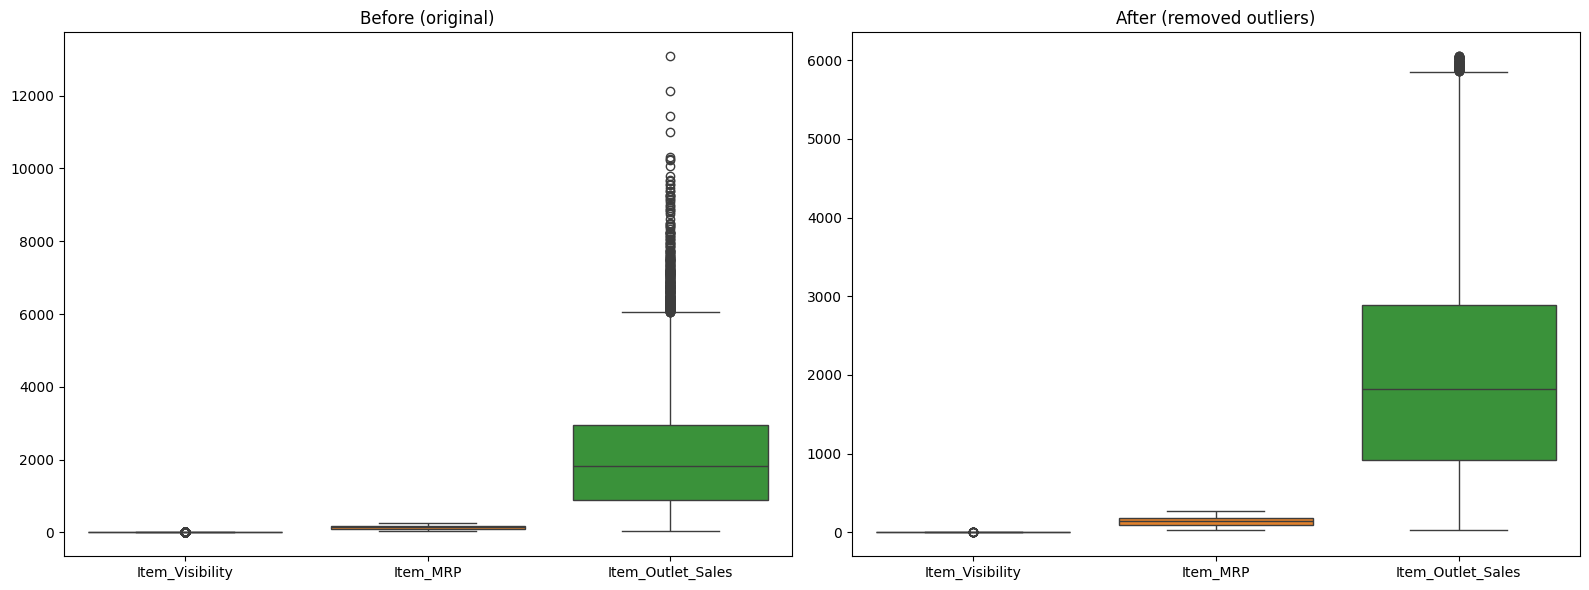

In [ ]:
# Вычислим границы IQR по исходному датасету (не пересчитывая их после удаления)
bounds = {}
orig_outlier_counts = {}
for col in num_cols:
    col_nonan = df[col].dropna()
    Q1 = col_nonan.quantile(0.25)
    Q3 = col_nonan.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    bounds[col] = (lower, upper)
    orig_outlier_counts[col] = ((df[col] < lower) | (df[col] > upper)).sum()

print("\nOutliers per column (original bounds):")
for c, cnt in orig_outlier_counts.items():
    print(f"  {c}: {cnt}")

# Маска строк, где есть хотя бы один выброс (по оригинальным границам)
mask_any_outlier = np.zeros(len(df), dtype=bool)
for col, (lower, upper) in bounds.items():
    mask_any_outlier |= df[col].notna() & ((df[col] < lower) | (df[col] > upper))

print("\nTotal rows with any outlier (will be removed):", mask_any_outlier.sum())

# Создаём очищенный df и сохраняем
df_clean = df.loc[~mask_any_outlier].copy()
print("Shape before:", df.shape, "after:", df_clean.shape, "removed:", df.shape[0] - df_clean.shape[0])

df_clean.to_csv('../data/bigmart_sales_clean.csv', index=False)
print("Saved: ../data/bigmart_sales_clean.csv")

# Проверка — по тем же исходным границам больше не должно быть выбросов
print("\nOutliers per column after cleaning (should be 0):")
for col in num_cols:
    lower, upper = bounds[col]
    cnt = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f"  {col}: {cnt}")

# Нарисуем боксплоты ДО и ПОСЛЕ для наглядности (выбери интересующие столбцы)
cols_to_plot = ['Item_Visibility', 'Item_MRP', 'Item_Outlet_Sales']
cols_to_plot = [c for c in cols_to_plot if c in num_cols]

fig, axes = plt.subplots(1, 2, figsize=(16,6))
sns.boxplot(data=df[cols_to_plot], ax=axes[0])
axes[0].set_title('Before (original)')
sns.boxplot(data=df_clean[cols_to_plot], ax=axes[1])
axes[1].set_title('After (removed outliers)')
plt.tight_layout()
plt.show()
